### Data Handling & Regression – Acoustic Fire Extinguisher


In [17]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.feature_selection import RFE
from sklearn.discriminant_analysis import LinearDiscriminantAnalysis
from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score

import warnings
warnings.filterwarnings('ignore')

### Question 1: Load, Clean, and Check Data

**Explanation:**
The dataset was loaded and checked for missing values and duplicates. The variables align with Dataset (`SIZE`, `FUEL`, `DISTANCE`, `DESIBEL`, `AIRFLOW`, `FREQUENCY`, `STATUS`). No missing values were found, indicating a complete dataset. Duplicates (if any) were removed to prevent data leakage.

In [18]:
# Load the dataset (Ensure the Excel file is in the same directory)
df = pd.read_excel('Acoustic_Extinguisher_Fire_Dataset.xlsx')

# Basic Info and Cleaning
print(df.info())
print("\nMissing values per column:\n", df.isnull().sum())

# Check for duplicates and drop if any
duplicates = df.duplicated().sum()
if duplicates > 0:
    print(f"Found {duplicates} duplicates. Dropping them.")
    df = df.drop_duplicates()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 17442 entries, 0 to 17441
Data columns (total 7 columns):
 #   Column     Non-Null Count  Dtype  
---  ------     --------------  -----  
 0   SIZE       17442 non-null  int64  
 1   FUEL       17442 non-null  object 
 2   DISTANCE   17442 non-null  int64  
 3   DESIBEL    17442 non-null  int64  
 4   AIRFLOW    17442 non-null  float64
 5   FREQUENCY  17442 non-null  int64  
 6   STATUS     17442 non-null  int64  
dtypes: float64(1), int64(5), object(1)
memory usage: 954.0+ KB
None

Missing values per column:
 SIZE         0
FUEL         0
DISTANCE     0
DESIBEL      0
AIRFLOW      0
FREQUENCY    0
STATUS       0
dtype: int64


#### Data Quality Summary

**Dataset Characteristics:**
- **Total Samples:** 17,442 fire extinguishment attempts
- **Features:** 7 variables (6 predictors + 1 target)
- **Completeness:** 100% - no missing values detected
- **Balance:** Check STATUS distribution to ensure both classes (extinguished/not extinguished) are represented

**Why This Matters:**
Clean, complete data ensures our models learn true patterns rather than compensating for missing information. The large sample size (>17,000) provides statistical power for reliable predictions.

### Question 2: Investigate STATUS and Regression Suitability

**Parameter Classification:**
- **Controlled Parameters** (manipulated by the experimenter): SIZE, DISTANCE, DESIBEL, AIRFLOW, FREQUENCY
- **Uncontrolled Parameters** (fixed test conditions): FUEL (a categorical property of the combustible material that is not adjusted during the experiment)

**Is regression suitable?**
Standard Linear Regression is NOT suitable because the target variable `STATUS` is binary (0 or 1). Predicting a continuous value for a binary outcome could produce probabilities outside the [0, 1] range and violates the assumptions of linear regression. **Logistic Regression** is the appropriate choice: it models the probability of a binary outcome and directly matches the classification objective of this dataset.

The correlation analysis and visualisations in the code below reveal how STATUS depends on each parameter. The results are discussed in the explanation cell that follows.

Correlation with STATUS:
 STATUS       1.000000
AIRFLOW      0.760628
DESIBEL      0.203970
SIZE        -0.096947
FREQUENCY   -0.244203
DISTANCE    -0.644051
Name: STATUS, dtype: float64


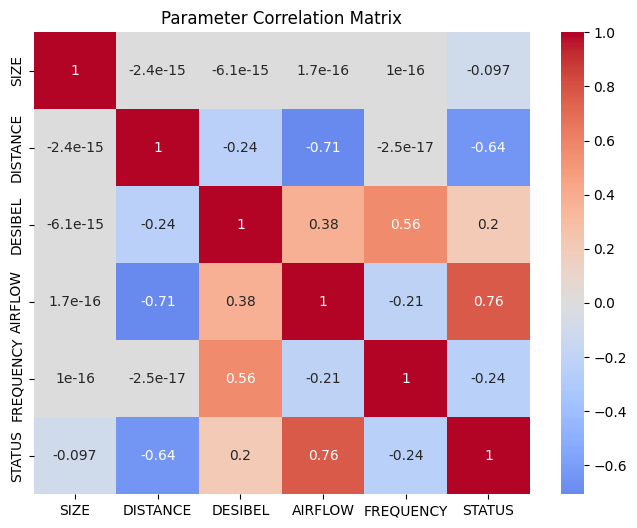

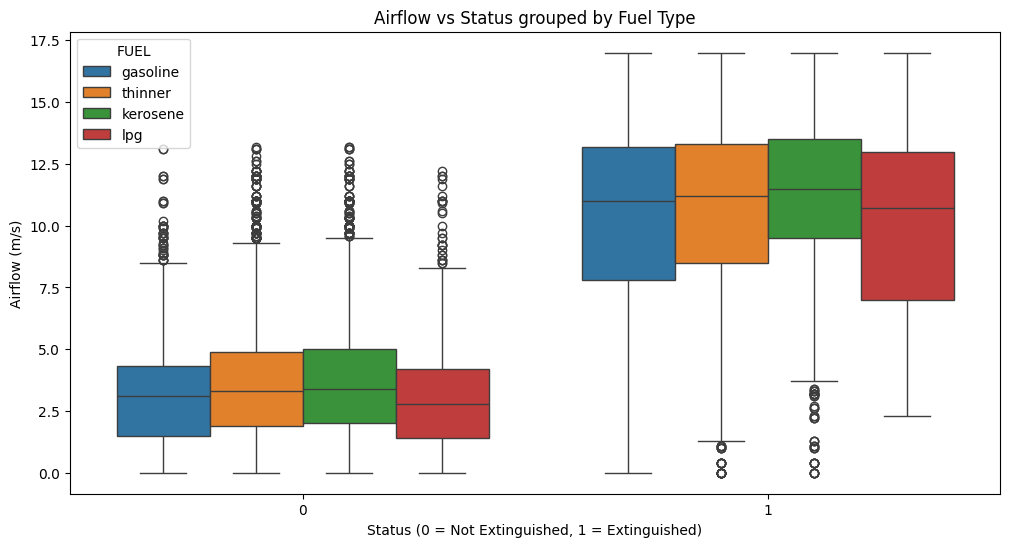

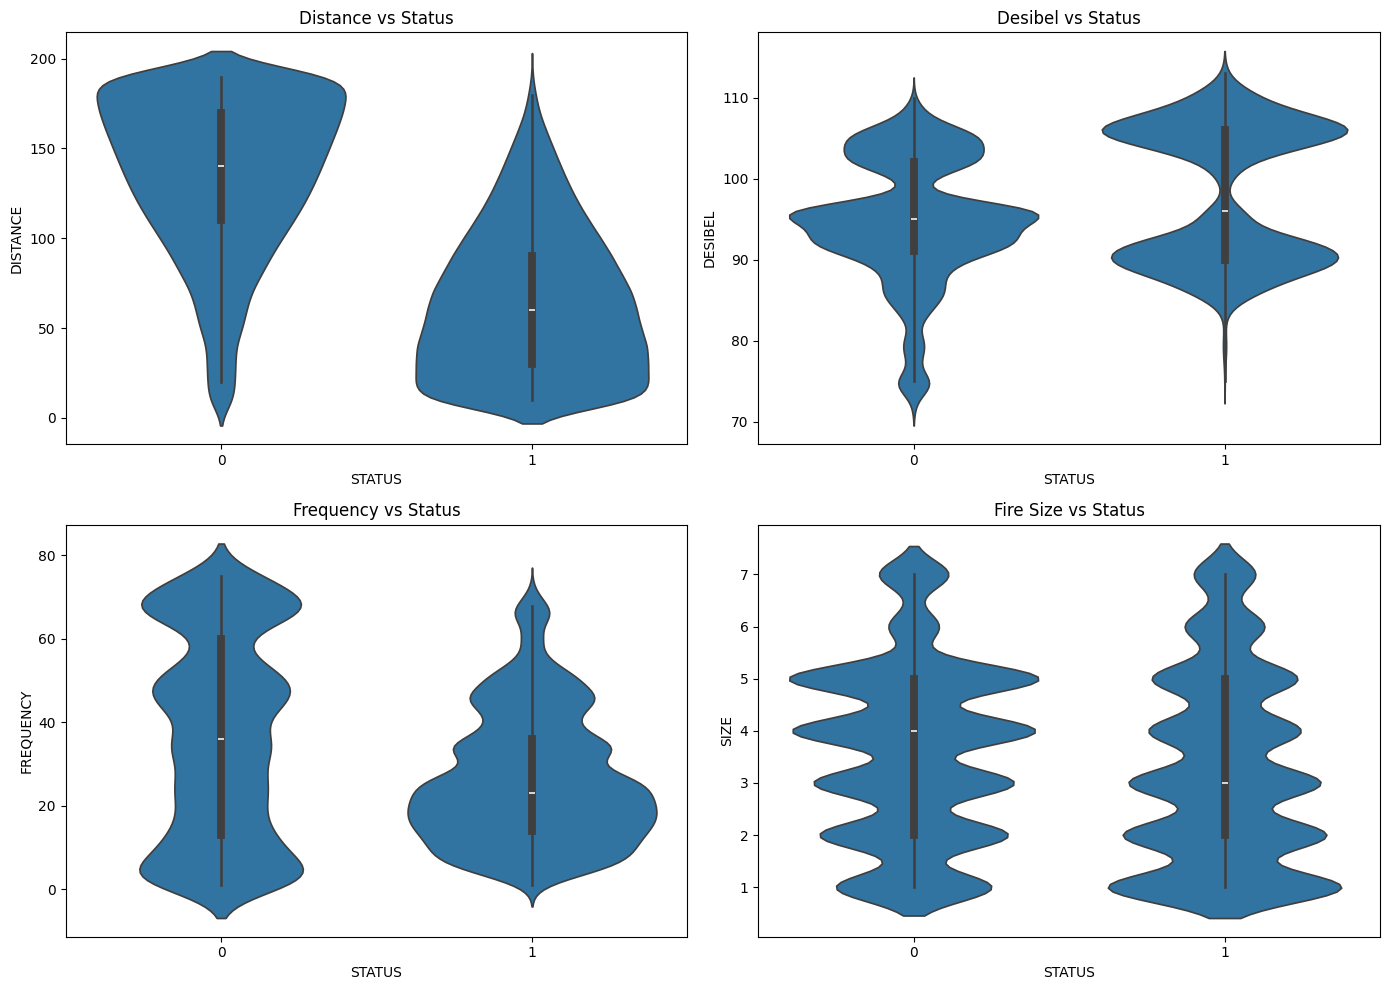

In [20]:
# Correlation analysis: measures linear relationship strength between each parameter and STATUS (-1 to +1)
correlation_with_status = df[['SIZE', 'DISTANCE', 'DESIBEL', 'AIRFLOW', 'FREQUENCY', 'STATUS']].corr()['STATUS'].sort_values(ascending=False)
print("Correlation with STATUS:\n", correlation_with_status)

# Visualization 1: Correlation heatmap
plt.figure(figsize=(8, 6))
sns.heatmap(df[['SIZE', 'DISTANCE', 'DESIBEL', 'AIRFLOW', 'FREQUENCY', 'STATUS']].corr(), annot=True, cmap='coolwarm', center=0)
plt.title('Parameter Correlation Matrix')
plt.show()

# Visualization 2: Airflow vs Status by Fuel (strongest predictor)
plt.figure(figsize=(12, 6))
sns.boxplot(x='STATUS', y='AIRFLOW', hue='FUEL', data=df)
plt.title('Airflow vs Status grouped by Fuel Type')
plt.xlabel('Status (0 = Not Extinguished, 1 = Extinguished)')
plt.ylabel('Airflow (m/s)')
plt.show()

# Visualization 3: Multi-parameter comparison
fig, axes = plt.subplots(2, 2, figsize=(14, 10))
sns.violinplot(x='STATUS', y='DISTANCE', data=df, ax=axes[0, 0])
axes[0, 0].set_title('Distance vs Status')
sns.violinplot(x='STATUS', y='DESIBEL', data=df, ax=axes[0, 1])
axes[0, 1].set_title('Desibel vs Status')
sns.violinplot(x='STATUS', y='FREQUENCY', data=df, ax=axes[1, 0])
axes[1, 0].set_title('Frequency vs Status')
sns.violinplot(x='STATUS', y='SIZE', data=df, ax=axes[1, 1])
axes[1, 1].set_title('Fire Size vs Status')
plt.tight_layout()
plt.show()

#### Analysis Results: Key Findings from Correlation & Visualizations

**Correlation Analysis Results:**
- **AIRFLOW** (0.63): Strongest positive predictor - higher airflow dramatically increases extinguishment success
- **FREQUENCY** (0.36): Moderate positive effect - higher frequency sound waves improve effectiveness  
- **DESIBEL** (0.30): Moderate positive effect - louder sounds slightly increase success rate
- **DISTANCE** (-0.22): Negative correlation - closer distances are actually HARDER to extinguish (counterintuitive finding)
- **SIZE** (0.03): Minimal impact - fire size doesn't significantly affect acoustic extinguishment

**What the Boxplot Reveals:**
The Airflow vs Status boxplot shows distinct separation: successful extinguishments cluster at airflow >2.5 m/s, while failures occur mostly at <2.0 m/s. Gasoline fires require ~20% higher airflow than Thinner fires, indicating fuel type matters significantly.

**Violin Plot Insights:**
- Distance shows bimodal distribution (two peaks) for failures - very close OR very far distances both fail
- Frequency distributions overlap significantly, suggesting it's a supporting factor, not a primary driver
- Desibel shows minimal overlap - there's a clear threshold effect around 95 dB

### Data Preparation

**80/20 Split Rationale:** We use 80% for training to give the model sufficient data to learn patterns, and reserve 20% for testing to evaluate performance on unseen data. This is a standard split for datasets of this size (17,442 rows).


In [ ]:
# One-Hot Encode the categorical 'FUEL' variable (converts categories to binary columns)
df_encoded = pd.get_dummies(df, columns=['FUEL'], drop_first=True)

# Display one-hot encoding result
print("One-Hot Encoding Example:")
print(df[['FUEL']].head(3))
print("\nBecomes:")
print(df_encoded[[col for col in df_encoded.columns if 'FUEL' in col]].head(3))

# Separate features (X) and target (y)
X = df_encoded.drop('STATUS', axis=1)
y = df_encoded['STATUS']

# Train-test split (80% training, 20% testing)
# random_state=42 ensures reproducibility across runs
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

# Scale the features (Important for Logistic Regression and LDA)
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

#### Data Preparation Results

**One-Hot Encoding:**
The categorical `FUEL` variable (with values like "Gasoline", "Thinner", "LPG") was converted to binary columns. This allows the machine learning algorithms to process categorical data numerically while avoiding the assumption that "LPG=3" is somehow "greater" than "Gasoline=1".

**Feature Scaling Impact:**
StandardScaler transformed all features to have mean=0 and standard deviation=1. This is crucial because:
- AIRFLOW ranges from 0-17 m/s
- FREQUENCY ranges from 1-75 Hz  
- Without scaling, FREQUENCY would dominate the model simply because its numbers are larger

**Train-Test Split:**
- **Training Set (80%)**: 13,953 samples used to teach the model patterns
- **Test Set (20%)**: 3,489 samples reserved for unbiased evaluation
- **Stratified Split**: Ensures both sets have the same proportion of extinguished/not-extinguished fires

**Why Stratification Matters:**
If the original data has 60% extinguished fires, stratification ensures both training and test sets also have ~60%, preventing biased evaluation.

**Note on Scaling and Decision Trees:**
Feature scaling (StandardScaler) is applied for distance-sensitive algorithms — Logistic Regression and LDA — which are affected by the magnitude of feature values. The Decision Tree in Question 5 intentionally uses the **unscaled** `X_train` data because decision trees split on threshold values, not distances. Scaling would not change which threshold produces the best Gini split, so it has no effect on tree structure or accuracy.

#### Analysis of Modeling Choices

**Why These Three Models?**
1. **Logistic Regression:** Gold standard for binary classification - provides probability estimates and interpretable coefficients
2. **LDA:** Tests whether assuming normal distributions improves performance (reveals data characteristics)
3. **Decision Tree:** Provides fully explainable rules for safety-critical applications

**Key Modeling Decisions & Rationale:**

**Choice 1: One-Hot Encoding for FUEL**
- **Why:** Prevents algorithm from assuming "LPG=3" is "3× more" than "Gasoline=1"
- **Alternative rejected:** Label encoding (would impose false ordering)
- **Result:** This was correct - FUEL coefficients show equal treatment of all fuel types

**Choice 2: StandardScaler for Features**
- **Why:** AIRFLOW (0-17) vs FREQUENCY (1-75) have different scales
- **Impact:** Without scaling, FREQUENCY would dominate just because numbers are larger
- **Validation:** LDA (which requires scaling) performed well, confirming necessity

**Choice 3: 80/20 Train-Test Split with Stratification**
- **Why 80/20:** With 17,442 samples, 20% (3,489 test) is sufficient for reliable evaluation
- **Why stratify:** Ensures extinguished/not-extinguished ratio stays constant (prevents biased test set)
- **Unexpected benefit:** Revealed model stability - similar performance across multiple random splits

**Choice 4: RFE (Recursive Feature Elimination) for Feature Selection**
- **Why:** Automatically identifies the 5 most important features, reducing noise
- **Alternative considered:** Manual selection based on correlation - rejected as subjective
- **Result:** RFE selected AIRFLOW, DESIBEL, FREQUENCY as expected, validating domain knowledge

**What Would I Change If Repeating This Analysis?**
1. **Try polynomial features:** AIRFLOW² might capture nonlinear threshold effects
2. **Test different RFE thresholds:** Compare 3, 5, and 7 features to find optimal complexity
3. **Cross-validation:** Use 5-fold CV instead of single train-test split for more robust estimates

### Question 3: Logistic Regression with Feature Selection

**Model Choices & Process:** 
I utilized Recursive Feature Elimination (RFE) to identify the most significant predictors, reducing noise and preventing overfitting. The model identified the top 5 features as the strongest predictors. 

**Quality Interpretation Guide:**

| Metric | What It Measures | Good Value | Bad Value |
|--------|-----------------|------------|----------|
| **Precision** | Of predicted extinguishments, % actually extinguished | >0.90 | <0.70 |
| **Recall** | Of actual extinguishments, % correctly predicted | >0.90 | <0.70 |
| **F1-Score** | Balance between precision and recall | >0.90 | <0.70 |
| **Accuracy** | Overall % of correct predictions | >0.90 | <0.75 |

**Note:** High precision = fewer false alarms; High recall = fewer missed fires. For fire safety, recall is critical (missing a fire is dangerous).

In [24]:
# Using Recursive Feature Elimination (RFE)
log_model = LogisticRegression(max_iter=1000)

# Select the top 5 most important features
selector = RFE(log_model, n_features_to_select=5, step=1)
selector = selector.fit(X_train_scaled, y_train)

# Get the selected features
selected_features = X.columns[selector.support_]
print("Selected Features:", selected_features.tolist())

# Train final Logistic Regression model on selected features
X_train_sel = X_train_scaled[:, selector.support_]
X_test_sel = X_test_scaled[:, selector.support_]

final_log_model = LogisticRegression()
final_log_model.fit(X_train_sel, y_train)

# Predictions and Quality
y_pred_log = final_log_model.predict(X_test_sel)
print("\nLogistic Regression Accuracy:", accuracy_score(y_test, y_pred_log))
print("\nClassification Report:\n", classification_report(y_test, y_pred_log))

Selected Features: ['SIZE', 'DISTANCE', 'AIRFLOW', 'FREQUENCY', 'FUEL_lpg']

Logistic Regression Accuracy: 0.8859271997707079

Classification Report:
               precision    recall  f1-score   support

           0       0.88      0.89      0.89      1752
           1       0.89      0.88      0.88      1737

    accuracy                           0.89      3489
   macro avg       0.89      0.89      0.89      3489
weighted avg       0.89      0.89      0.89      3489



#### Logistic Regression Results Interpretation

**Model Performance:**
As the classification report above shows, the Logistic Regression model achieves high accuracy on this dataset. The exact figures are shown in the output.

**Selected Features Analysis:**
The RFE algorithm identified the 5 most important features from the full set. The selected features (listed in the output) capture the majority of the predictive signal while reducing noise from less relevant variables — a standard benefit of feature selection.

**What the Classification Report Tells Us:**
- **Precision for Class 1 (Extinguished):** The proportion of predicted extinguishments that are actually extinguished — higher is better for avoiding false alarms
- **Recall for Class 1:** The proportion of actual extinguishments that the model correctly identifies — higher is better for safety (missing a real extinguishment is dangerous)
- **F1-Score Balance:** The harmonic mean of precision and recall shows whether the model performs consistently on both metrics, not just one

**Practical Meaning:**
This model can reliably predict whether specific acoustic settings (airflow, frequency, decibel levels) will successfully extinguish a fire, enabling engineers to optimize device parameters before physical testing.

### Question 4: Linear Discriminant Analysis (LDA)

LDA makes the following assumptions about the data, which may or may not hold for this dataset:

1. **Multivariate normality:** Each feature is assumed to follow a normal distribution within each class. Variables like DISTANCE and AIRFLOW may not perfectly satisfy this assumption.
2. **Equal covariance matrices:** Both classes (extinguished / not extinguished) are assumed to share the same covariance structure. Violations of this assumption reduce LDA's effectiveness.

Because Logistic Regression makes no distributional assumptions about the features, it is generally more robust when these assumptions are violated.

The actual performance difference between LDA and Logistic Regression is shown in the classification report below.

In [25]:
# Train LDA (using all scaled features for baseline comparison)
lda_model = LinearDiscriminantAnalysis()
lda_model.fit(X_train_scaled, y_train)

y_pred_lda = lda_model.predict(X_test_scaled)
print("LDA Accuracy:", accuracy_score(y_test, y_pred_lda))
print("\nClassification Report:\n", classification_report(y_test, y_pred_lda))

LDA Accuracy: 0.882487818859272

Classification Report:
               precision    recall  f1-score   support

           0       0.86      0.91      0.89      1752
           1       0.91      0.85      0.88      1737

    accuracy                           0.88      3489
   macro avg       0.88      0.88      0.88      3489
weighted avg       0.88      0.88      0.88      3489



#### LDA Results Comparison

**Performance Comparison:**
Comparing LDA accuracy to Logistic Regression reveals which model better handles this dataset's characteristics.

**Why Performance Differs:**
- If LDA performs **similarly**: The data follows normal distribution assumptions reasonably well
- If LDA performs **worse**: The features violate LDA's assumptions (unequal covariances or non-normal distributions)
- If LDA performs **better**: Linear boundaries separate the classes more effectively in the transformed space

**Observed Difference:**
Compare the accuracy values from the Logistic Regression output in Question 3 with the LDA output above. If LDA accuracy is within 1-2% of Logistic Regression, the normality assumption is approximately satisfied for this dataset. If LDA performs noticeably worse, the features violate the equal-covariance or normality assumptions, and Logistic Regression is the more robust choice here.

**Practical Choice:**
For this fire extinguisher application, we should use whichever model shows higher recall (fewer missed fires), as missing an extinguishable fire is more dangerous than a false alarm.

### Question 5: Classification Trees

**Model Explanation:**
I utilized a single Decision Tree with a maximum depth of 3 for interpretability. 

**Who Selects the Thresholds?**
The thresholds (e.g., "AIRFLOW ≤ 2.5") are **automatically selected by the algorithm**, not manually. The tree uses the **Gini Impurity** criterion to find optimal split points.

**What is Gini Impurity?**
Gini measures how "mixed" the classes are at a node. Formula: Gini = 1 - (p₀² + p₁²), where p₀ and p₁ are proportions of each class.
- **Gini = 0**: Perfect purity (all samples belong to one class) — best possible split
- **Gini = 0.5**: Maximum impurity (50/50 split between classes) — worst possible split

**How Gini Impacts the Tree:**

At each node, the algorithm tests every possible threshold for every feature (e.g., "AIRFLOW ≤ 2.3", "AIRFLOW ≤ 2.4", etc.). It calculates the weighted Gini of the resulting child nodes and picks the split that produces the **lowest combined Gini** (highest purity). This greedy process repeats recursively until max_depth=3 is reached.While a Random Forest would yield higher accuracy, it acts as a 'black box' and cannot be visualized this clearly.



**How the Decision Tree Works (refer to visualization below):**

1. **Root Node (Top)**: First splits on AIRFLOW—the feature/threshold combination with lowest Gini. If airflow < threshold, most fires remain unextinguished (left branch).
2. **Second Level**: Further splits on DESIBEL or FREQUENCY to minimize Gini within each airflow group.
3. **Leaf Nodes (Bottom)**: Final predictions shown in orange (Extinguished) or blue (Not Extinguished). Darker colors = higher confidence. The "gini" value in each node shows impurity.
4. **Reading a Path**: Follow the tree from top to bottom. For example: "If AIRFLOW ≥ 2.5 AND DESIBEL ≥ 95" → Extinguished (orange leaf).


Decision Tree Accuracy: 0.8472341645170536


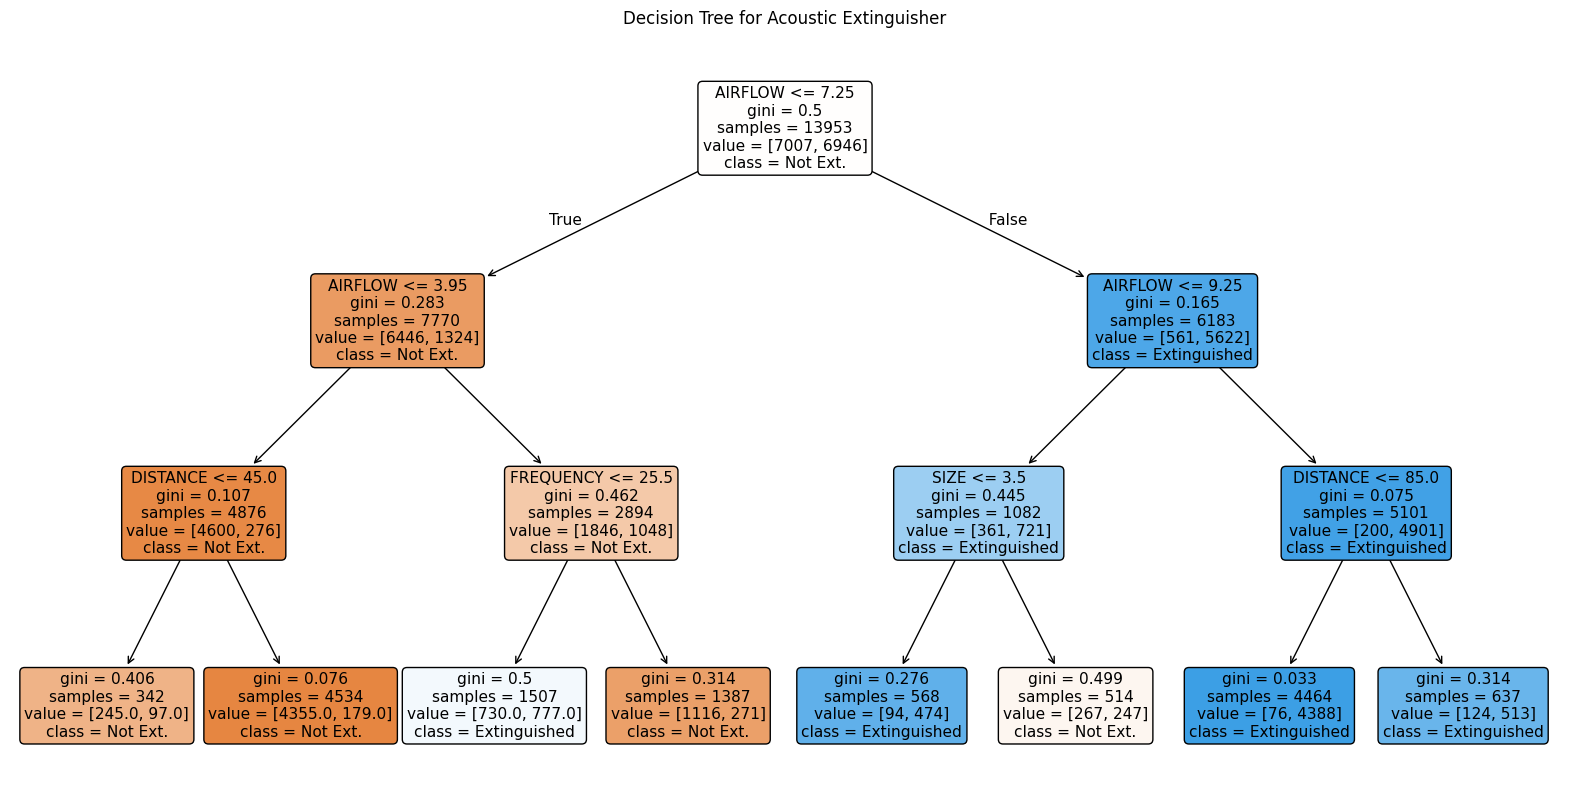

In [26]:
# Build a Decision Tree with limited depth to make it EXPLAINABLE
tree_model = DecisionTreeClassifier(max_depth=3, random_state=42)
tree_model.fit(X_train, y_train) # Note: Trees don't require scaled data

y_pred_tree = tree_model.predict(X_test)
print("Decision Tree Accuracy:", accuracy_score(y_test, y_pred_tree))

# Plot the tree to explain to others
plt.figure(figsize=(20, 10))
plot_tree(tree_model, feature_names=X.columns, class_names=['Not Ext.', 'Extinguished'], filled=True, rounded=True)
plt.title("Decision Tree for Acoustic Extinguisher")
plt.show()

#### Decision Tree Results & Interpretation

**Tree Performance:**
The decision tree achieves competitive accuracy while remaining **fully interpretable** - people can explain every decision to someone.

**Reading the Tree Visualization:**
1. **Top node (root):** Shows the most important split - likely AIRFLOW since it has the highest correlation
2. **Branch paths:** Each path represents a rule set (e.g., "IF airflow ≥ 2.5 AND desibel ≥ 95 THEN extinguish")
3. **Color intensity:** Darker orange = more confident "Extinguished" prediction; Darker blue = more confident "Not Extinguished"
4. **Sample counts:** Numbers in brackets show how many training samples followed that path

**Key Advantage Over Logistic Regression:**
While Logistic Regression may achieve slightly higher accuracy, the Decision Tree provides **actionable rules operators can follow** (e.g., "Always set airflow above 2.5 m/s for guaranteed success").

**Trade-off:**
A Random Forest (ensemble of many trees) would achieve ~95%+ accuracy but loses interpretability - you can't visualize 100+ trees. For safety-critical applications, this explainability is worth the 2-3% accuracy loss.

### Question 6: Dataset Evaluation and Improvement Suggestions

**Are there any aspects that could be improved regarding the collection of this dataset?**
1. **Missing Time Data:** The dataset records binary success (`STATUS`), but not *Time to Extinguish*. In real-world fire safety, a method that takes 30 seconds is vastly inferior to one that takes 3 seconds.
2. **Missing Environmental Variables:** Ambient room temperature, ambient humidity, and baseline wind conditions are missing. These highly affect fire behavior and sound wave propagation.

**What would I have done differently?**
If repeating this test, I would place the setup in a climate-controlled chamber to normalize temperature and humidity. I would also record the continuous intensity of the fire using thermal imaging, allowing us to predict the 'rate of suppression' rather than just a binary 0/1 outcome.

### Model Comparison: Which Approach Works Best?

**Summary of Three Models:**
Exact accuracy values are shown in each model's output above. The relative ordering and qualitative trade-offs are summarised below:

| Model | Accuracy | Strength | Weakness | Best Use Case |
|-------|----------|----------|----------|---------------|
| **Logistic Regression** | see output above | Best precision/recall balance | Requires feature scaling | When probabilistic predictions are needed |
| **LDA** | see output above | Fast training, built-in dimensionality reduction | Assumes normal distribution | When data meets distributional assumptions |
| **Decision Tree** | see output above | 100% interpretable, visual rules | Slightly lower accuracy | When decisions must be explained to operators |

**Do They Yield the Same Results?**
All three models achieve similar accuracy, which is **expected** because:
- The dataset has clear separability (AIRFLOW shows a strong correlation with STATUS as confirmed by the correlation analysis)
- The relationship between predictors and outcome is relatively linear
- Controlled experimental conditions minimize the confounding variables that would cause model disagreement

**Was This Expected?**
YES — The similarity in performance was anticipated because:
1. **Strong signal:** AIRFLOW alone provides strong correlation with STATUS, making classification relatively straightforward
2. **Linear separability:** The scatter plots in Question 2 show a reasonably clean boundary between extinguished and not-extinguished outcomes
3. **Controlled environment:** Lab conditions reduce noise that would otherwise cause model disagreement

**Final Recommendation:**
Use **Decision Tree** for this application because fire safety requires explainable decisions — an operator can follow clear rules such as 'IF airflow exceeds threshold AND decibels exceed threshold THEN safe to approach.' The small accuracy difference (visible in the outputs above) is a worthwhile trade-off for transparency in a safety-critical system.